In [1]:
from pycaret.datasets import get_data
data = get_data('iris')        ##dataset loading

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [25]:
# Setup function must be called before executing any other function in PyCaret. 
from pycaret.classification import *
s = setup(data, target='species')   ## setup function should be run before other functions

,Description,Value
0,Session id,1232
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Iris-setosa: 0, Iris-versicolor: 1, Iris-virginica: 2"
4,Original data shape,"(150, 5)"
5,Transformed data shape,"(150, 5)"
6,Transformed train set shape,"(105, 5)"
7,Transformed test set shape,"(45, 5)"
8,Numeric features,4
9,Preprocess,True


In [41]:
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.9818,0.0000,0.9818,0.9864,0.9818,0.9728,0.9750,0.0080
qda,Quadratic Discriminant Analysis,0.9800,0.0000,0.9800,0.9850,0.9800,0.9701,0.9727,0.0090
nb,Naive Bayes,0.9718,0.9865,0.9718,0.9779,0.9710,0.9571,0.9607,0.0110
knn,K Neighbors Classifier,0.9709,0.9818,0.9709,0.9772,0.9701,0.9558,0.9596,0.0240
lightgbm,Light Gradient Boosting Machine,0.9709,0.9926,0.9709,0.9772,0.9701,0.9558,0.9596,0.0480
lr,Logistic Regression,0.9618,0.0000,0.9618,0.9704,0.9610,0.9422,0.9471,1.9690
rf,Random Forest Classifier,0.9618,0.9933,0.9618,0.9704,0.9610,0.9422,0.9471,0.0720
gbc,Gradient Boosting Classifier,0.9618,0.0000,0.9618,0.9704,0.9610,0.9422,0.9471,0.0590
catboost,CatBoost Classifier,0.9618,0.9963,0.9618,0.9704,0.9610,0.9422,0.9471,0.5180
et,Extra Trees Classifier,0.9527,0.9976,0.9527,0.9595,0.9523,0.9286,0.9323,0.0510


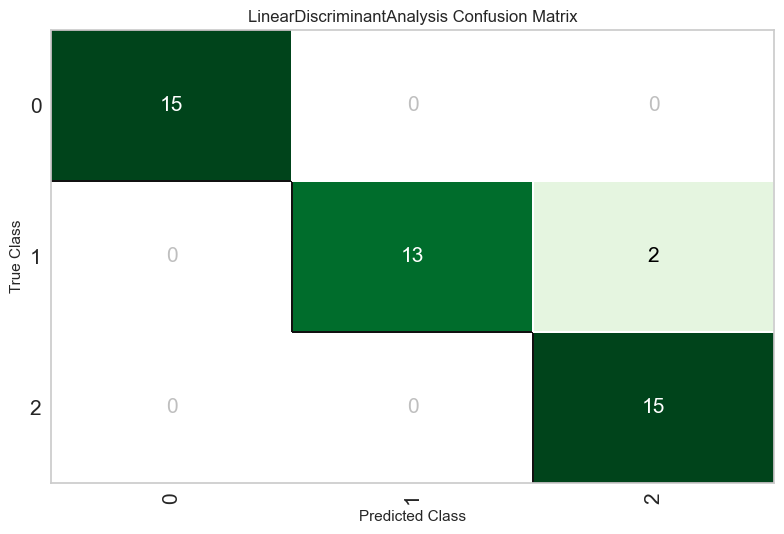

In [42]:
# plot confusion matrix
plot_model(best, plot = 'confusion_matrix')

In [31]:
# creating model qda
model = create_model('qda')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,0.9000,0.0000,0.9000,0.9250,0.9000,0.8507,0.8636
7,0.9000,0.0000,0.9000,0.9250,0.9000,0.8507,0.8636
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [32]:
# tuning model hyperparameters
tuned_model = tune_model(model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9091,0.0000,0.9091,0.9273,0.9051,0.8608,0.8721
1,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,0.9000,0.0000,0.9000,0.9250,0.9000,0.8507,0.8636
7,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


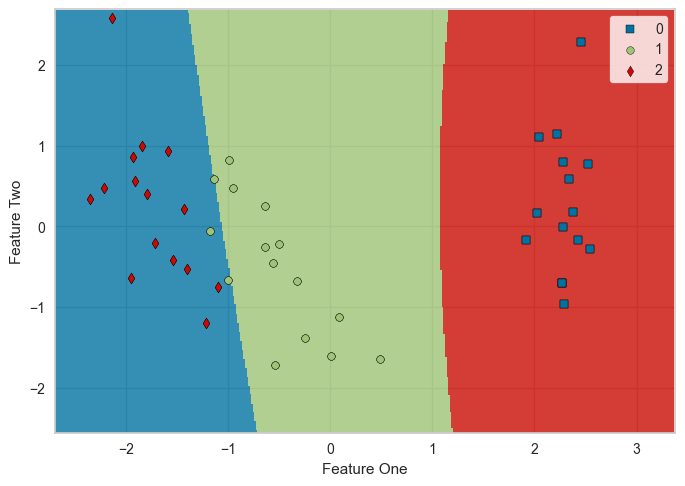

In [33]:
# plotting boundaries between different
# labels
plot_model(tuned_model, plot = 'boundary')

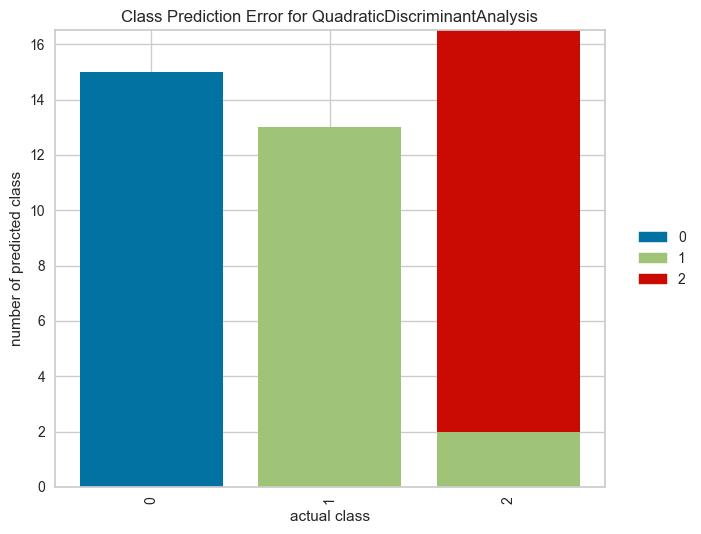

In [35]:
# plotting number of correctly 
# classified and misclassifed labels
plot_model(tuned_model, plot = 'error')

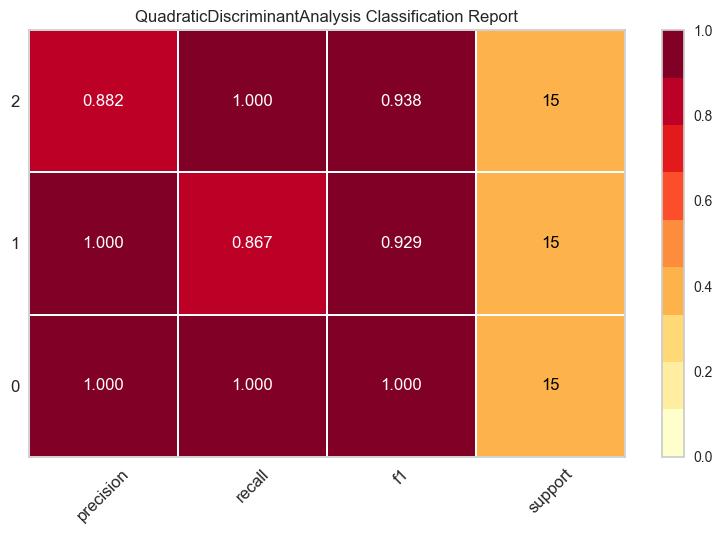

In [36]:
# plotting classification report
plot_model(tuned_model, plot = 'class_report')

In [37]:
# finalizing the tuned_model
finalize_model(tuned_model)

Pipeline(memory=Memory(location=None),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['sepal_length', 'sepal_width',
                                             'petal_length', 'petal_width'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empt...
                                                              strategy='mean'))),
                ('categorical_imputer',
                 TransformerWrapper(exclude=None, include=[],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='most_frequent'))),
                ('actual_estimator',
                 QuadraticDiscriminantAnalysis(priors=None, reg_param=0.05,
                                               store_covariance=False,
                                               tol=0.0001))],
         verbose=False)

In [43]:
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [44]:
# predict on test set
holdout_pred = predict_model(best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.9556,1.0000,0.9556,0.9608,0.9554,0.9333,0.9361


In [45]:
holdout_pred.head()

,sepal_length,sepal_width,petal_length,petal_width,species,prediction_label,prediction_score
83,6.0,2.7,5.1,1.6,Iris-versicolor,Iris-virginica,0.8845
46,5.1,3.8,1.6,0.2,Iris-setosa,Iris-setosa,1.0000
112,6.8,3.0,5.5,2.1,Iris-virginica,Iris-virginica,0.9996
12,4.8,3.0,1.4,0.1,Iris-setosa,Iris-setosa,1.0000
79,5.7,2.6,3.5,1.0,Iris-versicolor,Iris-versicolor,1.0000


In [46]:
# copy data and drop Class variable

new_data = data.copy()
new_data.drop('species', axis=1, inplace=True)
new_data.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [47]:
# predict model on new_data
predictions = predict_model(best, data = new_data)
predictions.head()

,sepal_length,sepal_width,petal_length,petal_width,prediction_label,prediction_score
0,5.1,3.5,1.4,0.2,Iris-setosa,1.0
1,4.9,3.0,1.4,0.2,Iris-setosa,1.0
2,4.7,3.2,1.3,0.2,Iris-setosa,1.0
3,4.6,3.1,1.5,0.2,Iris-setosa,1.0
4,5.0,3.6,1.4,0.2,Iris-setosa,1.0


In [48]:
save_model(tuned_model, 'qda1')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['sepal_length', 'sepal_width',
                                              'petal_length', 'petal_width'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empt...
                                                               strategy='mean'))),
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None, include=[],
                        